In [1]:
import os
import uuid
from typing import Annotated, List
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.llms import Ollama
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import Tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
from logger import LOG  # 假设你有一个名为 logger.py 的日志配置文件
import torch

# 加载环境变量，例如 OPENAI_API_KEY, TAVILY_API_KEY 等
load_dotenv()


# --- 1. 定义图的状态 ---
# State 是我们图的“状态”定义。它就像是图在每一步中传递的记忆或数据结构。
# 'messages' 是一个特殊字段，Annotated 和 add_messages 告诉 LangGraph
# 如何更新这个字段：不是替换它，而是在列表末尾追加新的消息。
# 这对于维护对话历史至关重要。
class State(TypedDict):
    messages: Annotated[list, add_messages]


class ChatBot:
    def __init__(self, config, db_path: str):
        """
        初始化 ChatBot 类。

        :param config: 配置对象，包含模型配置参数。
        :param db_path: 向量数据库文件路径。
        """
        self.config = config
        self.model_type = config.llm_model_type.lower()

        # --- 2. 初始化语言模型 ---
        LOG.info(f"正在初始化模型: {self.model_type}")
        if self.model_type == "openai":
            self.client = ChatOpenAI(model=self.config.openai_model_name, temperature=0)
        elif self.model_type == "ollama":
            self.client = Ollama(model=self.config.ollama_model_name)
        elif self.model_type == "gemini":
            self.client = ChatGoogleGenerativeAI(model=self.config.gemini_model_name, temperature=0)
        else:
            LOG.error(f"不支持的模型类型: {self.model_type}")
            raise ValueError(f"不支持的模型类型: {self.model_type}")
        LOG.info(f"模型 {self.model_type} 初始化成功。")

        # --- 3. 初始化工具 (向量检索 和 网络搜索) ---

        # 加载本地向量库作为检索器
        LOG.info("正在加载向量数据库...")
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.embeddings = HuggingFaceEmbeddings(
            model_name='BAAI/bge-base-zh-v1.5',
            model_kwargs={'device': device},
            encode_kwargs={'normalize_embeddings': True}
        )
        self.vectorstore = Chroma(
            persist_directory=db_path,
            embedding_function=self.embeddings,
        )
        # k=5 表示返回最相似的5个结果
        self.retriever = self.vectorstore.as_retriever(search_type='similarity', search_kwargs={"k": 5})
        LOG.info(f"加载向量数据库成功，路径: {db_path}")

        # 初始化 Tavily 网络搜索工具
        self.tavily_search = TavilySearch(max_results=5)
        LOG.info("Tavily 搜索工具初始化成功。")

        # 将功能封装成 LangChain 的 Tool 对象
        # 这是让 LLM "知道" 它有哪些工具可以使用的关键步骤。
        # `name` 是 LLM 调用工具时使用的名称。
        # `description` 至关重要，LLM 根据这个描述来判断在什么情况下应该使用这个工具。
        # `func` 是这个工具实际执行的函数。
        retriever_tool = Tool(
            name="vector_search",
            description="作为电信行业项目经理的专属工具，用于从安徽省政府官方发布的政策文件和会议纪要中深度挖掘商业机会。当需要为【政府、公共安全、公用事业、工商业】等目标客户设计解决方案时，应优先使用此工具。它能精准定位提及【人工智能、数字政府、智慧城市、工业互联网、系统集成、双招双引、未来产业】等关键词的文档，为制定涉及【云服务、软件开发、AI算力、网络通信及系统集成】的综合解决方案提供关键的政策依据和项目切入点。输入应为寻找商机的具体方向，例如‘分析今天文件中的数字政府商机’。",
            func=self.retriever.invoke
        )
        web_search_tool = Tool(
            name="web_search",
            description="作为商业机会分析的辅助工具，用于获取本地政策文件之外的补充信息。当从本地文件中发现一个商机（如‘智慧城市’或‘人工智能产业园’）后，可使用此工具进行深入研究。适用于查询相关技术的【市场规模、行业趋势、主流技术方案、潜在的竞争对手或合作伙伴】，以及查找政策中提到的具体企业或项目的【背景信息】。例如，在发现‘双招双引’政策后，可查询‘安徽省重点招商引资企业名单’。",
            func=self.tavily_search.invoke
        )
        self.tools = [retriever_tool, web_search_tool]
        # ToolExecutor 负责接收来自 LLM 的工具调用请求并执行它们
        self.tool_node = ToolNode(self.tools)
        LOG.info("工具集创建成功: [vector_search, web_search]")

        # 将工具绑定到模型，这样模型就知道它可以使用这些工具
        self.model_with_tools = self.client.bind_tools(self.tools)

        # --- 4. 初始化图和记忆 ---

        # MemorySaver 用于持久化存储每个对话线程的状态
        self.memory = MemorySaver()

        # 定义 LangGraph 工作流
        workflow = StateGraph(State)

        # 定义图中的节点
        workflow.add_node("agent", self.call_agent)
        workflow.add_node("action", self.tool_node)

        # 定义图中的边
        # 设置入口点为 'agent' 节点
        workflow.set_entry_point("agent")

        # 添加一个条件边。在 'agent' 节点之后，会调用 `should_continue` 函数判断下一步走向。
        # 如果 `should_continue` 返回 "continue"，则流程走向 'action' 节点。
        # 如果 `should_continue` 返回 "end"，则流程结束。
        workflow.add_conditional_edges(
            "agent",
            self.should_continue,
            {
                "continue": "action",
                "end": END,
            },
        )

        # 从 'action' 节点到 'agent' 节点有一条常规边。
        # 这形成了一个循环：Agent -> Action -> Agent ...
        workflow.add_edge("action", "agent")

        # 编译工作流，并连接检查点（记忆）
        # 这使得图的每一步状态都能被保存和恢复
        self.graph = workflow.compile(checkpointer=self.memory)
        LOG.info("LangGraph 工作流编译完成。")

    def call_agent(self, state: State) -> dict:
        """
        Agent 节点：调用带有工具的 LLM，决定下一步行动。
        """
        LOG.info("--- 调用 Agent 节点 ---")
        messages = state["messages"]
        # 调用绑定了工具的 LLM，它可能会返回一个直接的回答，或者一个工具调用请求
        response = self.model_with_tools.invoke(messages)
        LOG.info(f"Agent 响应: {response.content} | 工具调用: {response.tool_calls}")
        # 将 LLM 的响应添加到消息历史中，并返回更新后的状态
        return {"messages": [response]}

    def should_continue(self, state: State) -> str:
        """
        条件边逻辑：判断是继续执行工具还是结束。
        """
        LOG.info("--- 判断是否继续 ---")
        last_message = state["messages"][-1]
        # 如果最后一条消息中包含工具调用，说明需要继续执行 'action' 节点
        if last_message.tool_calls:
            LOG.info("决策: 继续 (调用工具)")
            return "continue"
        # 否则，说明 LLM 已经给出了最终答案，流程结束
        else:
            LOG.info("决策: 结束 (生成最终答案)")
            return "end"

    def invoke(self, question: str, thread_id: str) -> str:
        """
        对外暴露的调用接口，用于与机器人进行单次交互。

        :param question: 用户提出的问题。
        :param thread_id: 当前对话的唯一标识符，用于实现多轮记忆。
        :return: 模型的最终回答。
        """
        # 将用户问题封装成 LangChain 的消息格式
        input_message = {"messages": [HumanMessage(content=question)]}

        # 配置项，指定当前对话的线程 ID
        config = {"configurable": {"thread_id": thread_id}}

        # 调用图，LangGraph 会自动处理状态的加载、执行和保存
        final_state = self.graph.invoke(input_message, config)

        # 从最终状态中提取最后一条消息，即为模型的回答
        answer = final_state["messages"][-1].content
        return answer



In [2]:

# 确保你的 .env 文件中有 OPENAI_API_KEY, TAVILY_API_KEY, GOOGLE_API_KEY
from config import Config

# 向量数据库路径
db_path = r"D:\Python\PythonProject\GitHubSentinel\ah_gov\2025-07-14\chroma_db"

# 检查向量数据库是否存在，如果不存在，可以提示用户先运行数据爬取和嵌入的脚本
if not os.path.exists(db_path):
    print(f"错误：向量数据库路径 '{db_path}' 不存在。")
    print("请先运行数据处理脚本，创建向量数据库。")
    # 这里可以放一个创建向量库的示例，但根据题目要求，我们假设它已存在
    # from langchain_core.documents import Document
    # print("正在创建一个示例数据库...")
    # docs = [Document(page_content="安徽省会是合肥。", metadata={"source_url": "example.com", "title": "安徽省会"})]
    # embeddings = HuggingFaceEmbeddings(model_name='BAAI/bge-base-zh-v1.5')
    # Chroma.from_documents(documents=docs, embedding=embeddings, persist_directory=db_path)
    # print("示例数据库创建完成。")
    exit()

# 初始化 ChatBot
chatbot = ChatBot(Config(), db_path=db_path)


2025-07-17 09:56:29 | INFO | 2408112420:__init__:46 - 正在初始化模型: gemini
2025-07-17 09:56:29 | INFO | 2408112420:__init__:56 - 模型 gemini 初始化成功。
2025-07-17 09:56:29 | INFO | 2408112420:__init__:61 - 正在加载向量数据库...


D:\Python\PythonProject\GitHubSentinel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-07-17 09:56:39 | INFO | 2408112420:__init__:74 - 加载向量数据库成功，路径: D:\Python\PythonProject\GitHubSentinel\ah_gov\2025-07-14\chroma_db
2025-07-17 09:56:39 | INFO | 2408112420:__init__:78 - Tavily 搜索工具初始化成功。
2025-07-17 09:56:39 | INFO | 2408112420:__init__:98 - 工具集创建成功: [vector_search, web_search]
2025-07-17 09:56:39 | INFO | 2408112420:__init__:138 - LangGraph 工作流编译完成。


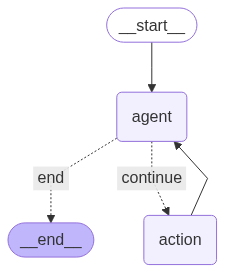

In [3]:
from IPython.display import Image, display

display(Image(chatbot.graph.get_graph().draw_mermaid_png()))